# Logistic linear regression -  

## 🔹 Logistic Regression
- **Use case**: जब output categorical हो (Yes/No, Spam/Not Spam, Disease/No Disease)।  
- Linear regression की तरह line नहीं बनाता, बल्कि **probability** निकालता है।  
- Jab multiple target feature ka data type categorical form me ho .

🔹 Logistic Regression में
Target variable हमेशा categorical होता है।

Binary classification → 1 target (Yes/No)

Multi-class classification → 1 target variable लेकिन कई possible classes (A/B/C)

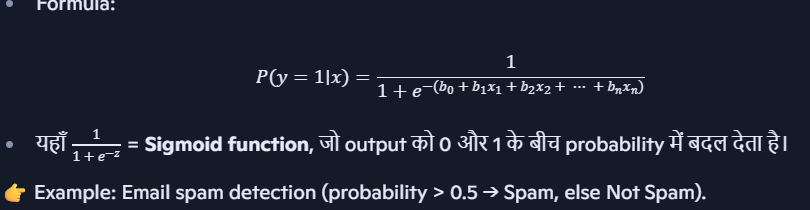


---
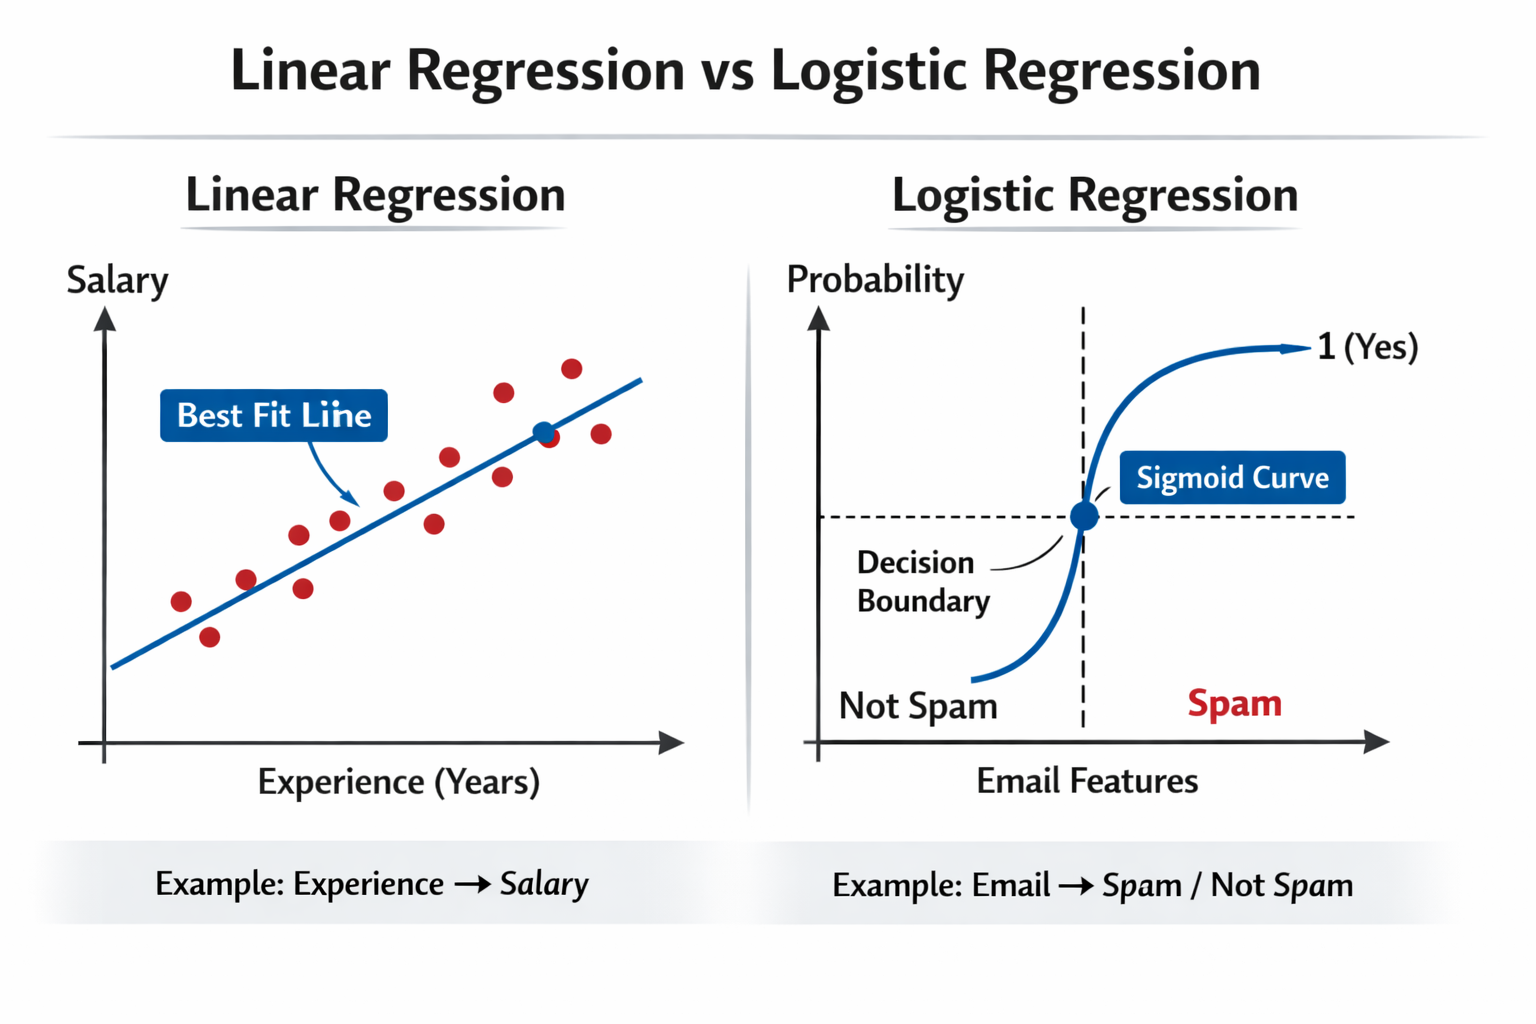
- Thresold graph ke andar second graph ka center ko thresold graph , sigmoid function

# Model Evolution metrix -
- classification  Model ki performance ko evaluate karta hai.
## Types
1. Confusion metrix - agar Binary hai 2 X 2 , Nominal hai to minmum 3 X 3

## 🎯 1. **Accuracy vs Error Rate**
- **Accuracy** बताता है कि कितने predictions सही हैं।  
- **Error Rate** बताता है कि कितने गलत हैं।  
    
            Error Rate = 1 − Accuracy

👉 Example: अगर Accuracy = 0.9 (90%)  
तो Error Rate = 0.1 (10%)  
मतलब 10% predictions गलत हैं।

---

## 🔹 2. **Precision**
- बताता है कि model ने जितने **positive predict किए**, उनमें से कितने **वास्तव में positive** थे।  


    -        Precision =    TP /             
                          TP + FP


👉 Example: Spam filter ने 100 emails को spam बताया, जिनमें से 80 सच में spam थे → Precision = 80/100 = 0.8 (80%)  
मतलब model ने spam prediction में 80% accuracy रखी।

---

## 🔹 3. **Recall (Sensitivity)**
- बताता है कि जितने **actual positive cases** थे, उनमें से model ने कितने पकड़े।  
  

-               Recall = TP /
                        TP + FN

  जहाँ  
  - FN = False Negative  

👉 Example: 100 actual spam emails थे, model ने 80 पकड़े → Recall = 80/100 = 0.8 (80%)  
मतलब model ने 80% spam emails पहचान लिए।

---

## 🔹 4. **F1 Score**
- Precision और Recall का **harmonic mean** है।  

-           F1 = 2( Precision X Recall )
                    Precision + Recall


- यह तब useful होता है जब dataset **imbalanced** हो (जैसे spam बहुत कम हों)।  
- F1 Score balance दिखाता है कि model precision और recall दोनों में कितना अच्छा है।

---


---

💡 **क्यों use करते हैं?**
- **Accuracy** → जब classes balanced हों।  
- **Precision** → जब false positives costly हों (e.g., non-spam को spam बताना)।  
- **Recall** → जब false negatives costly हों (e.g., disease miss करना)।  
- **F1 Score** → जब दोनों का balance चाहिए।

---



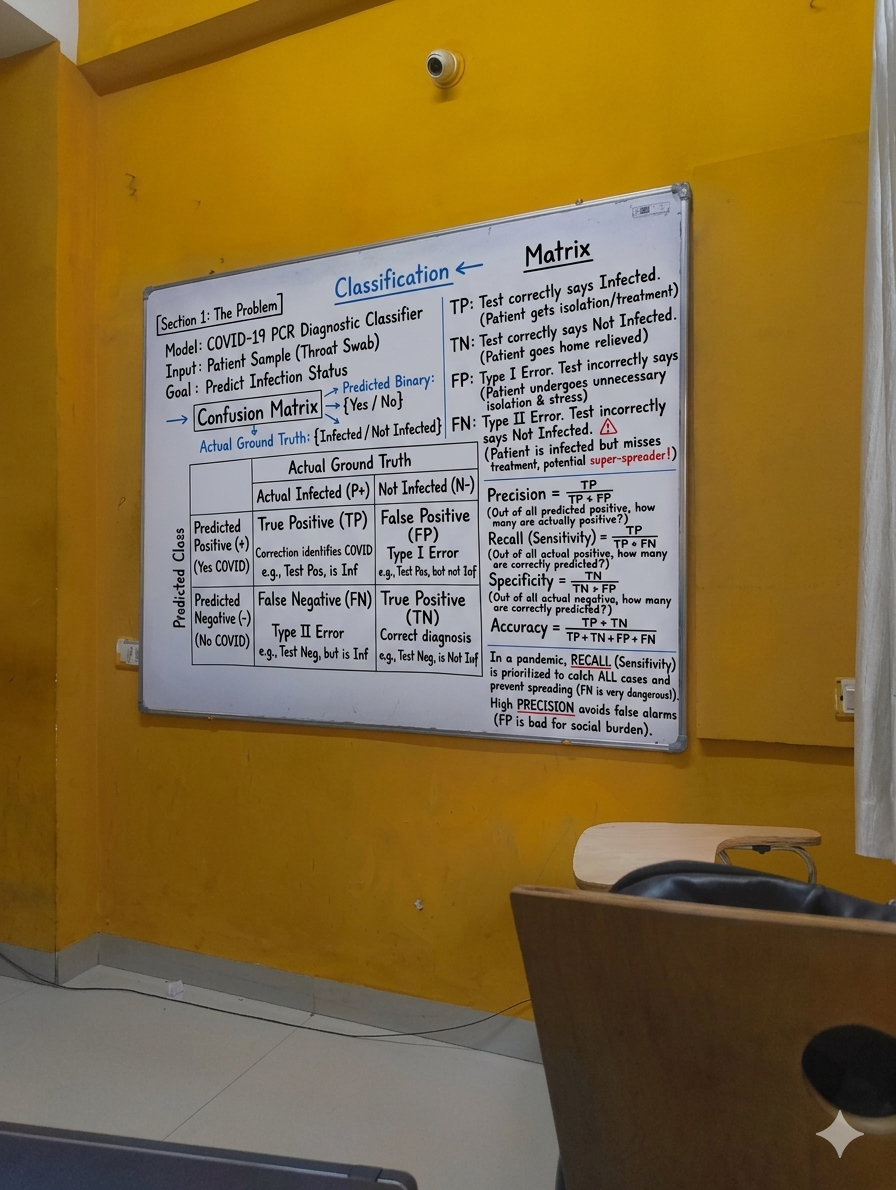

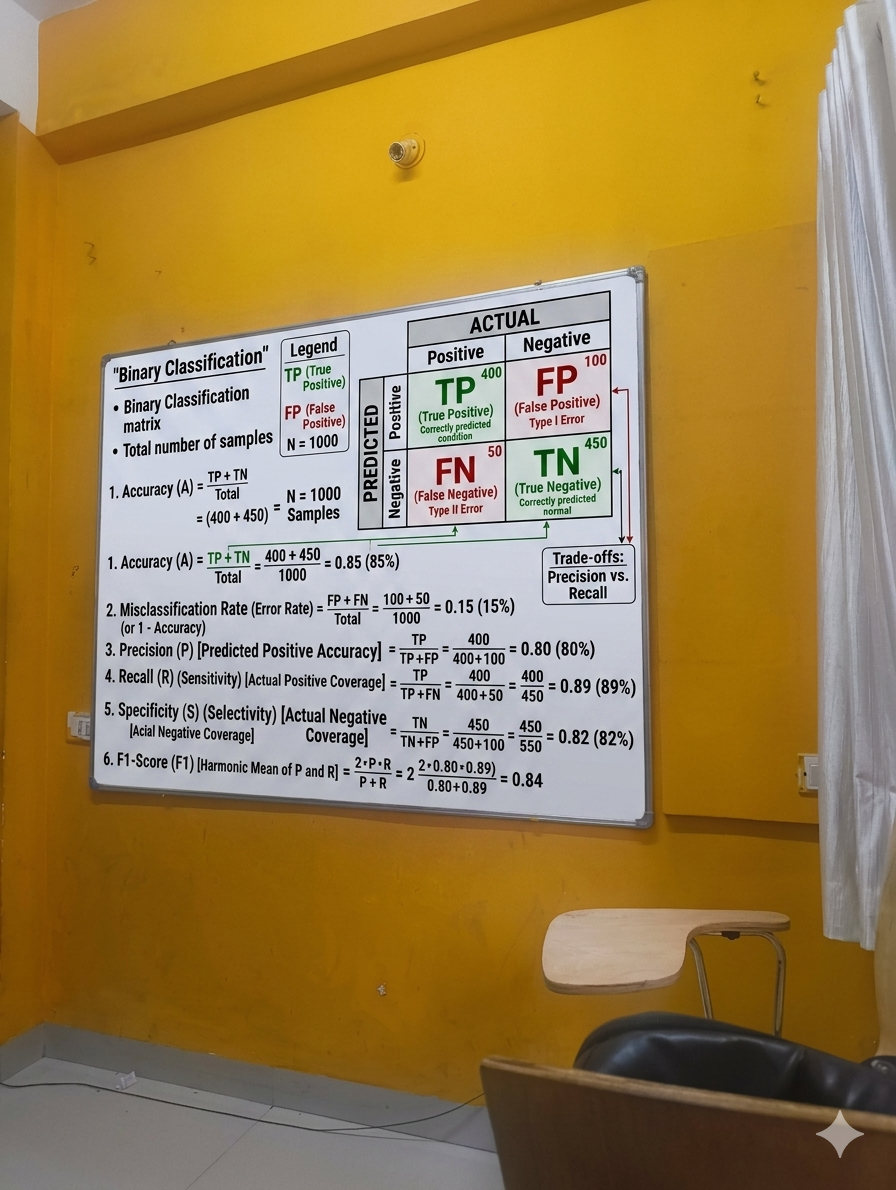

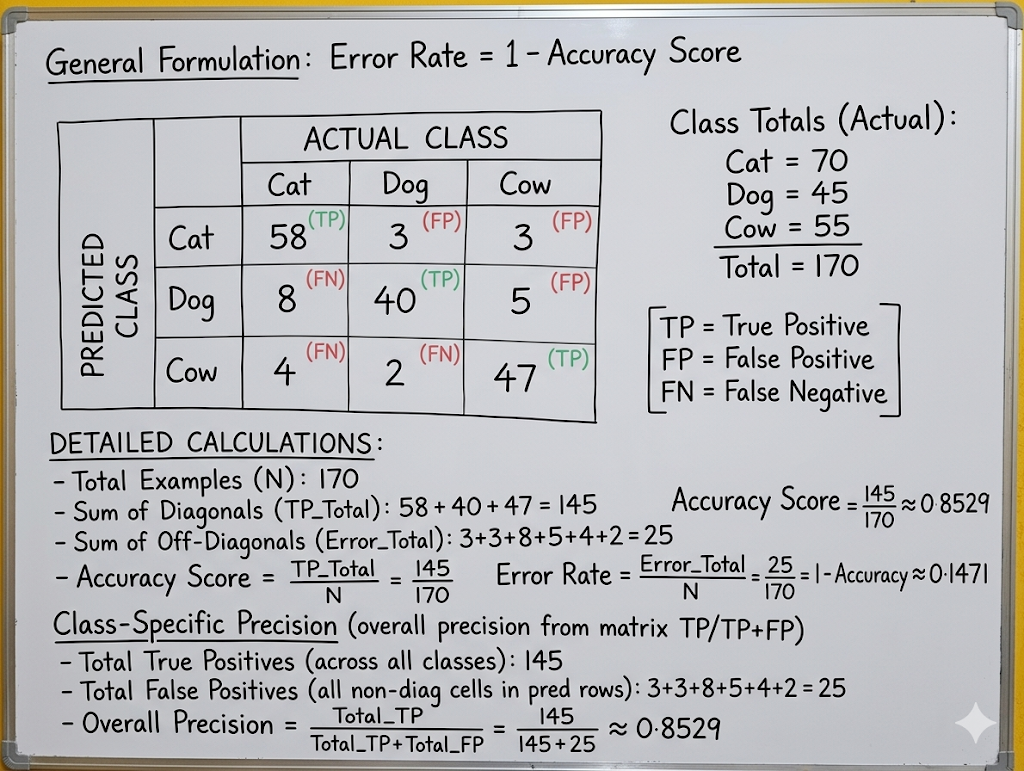

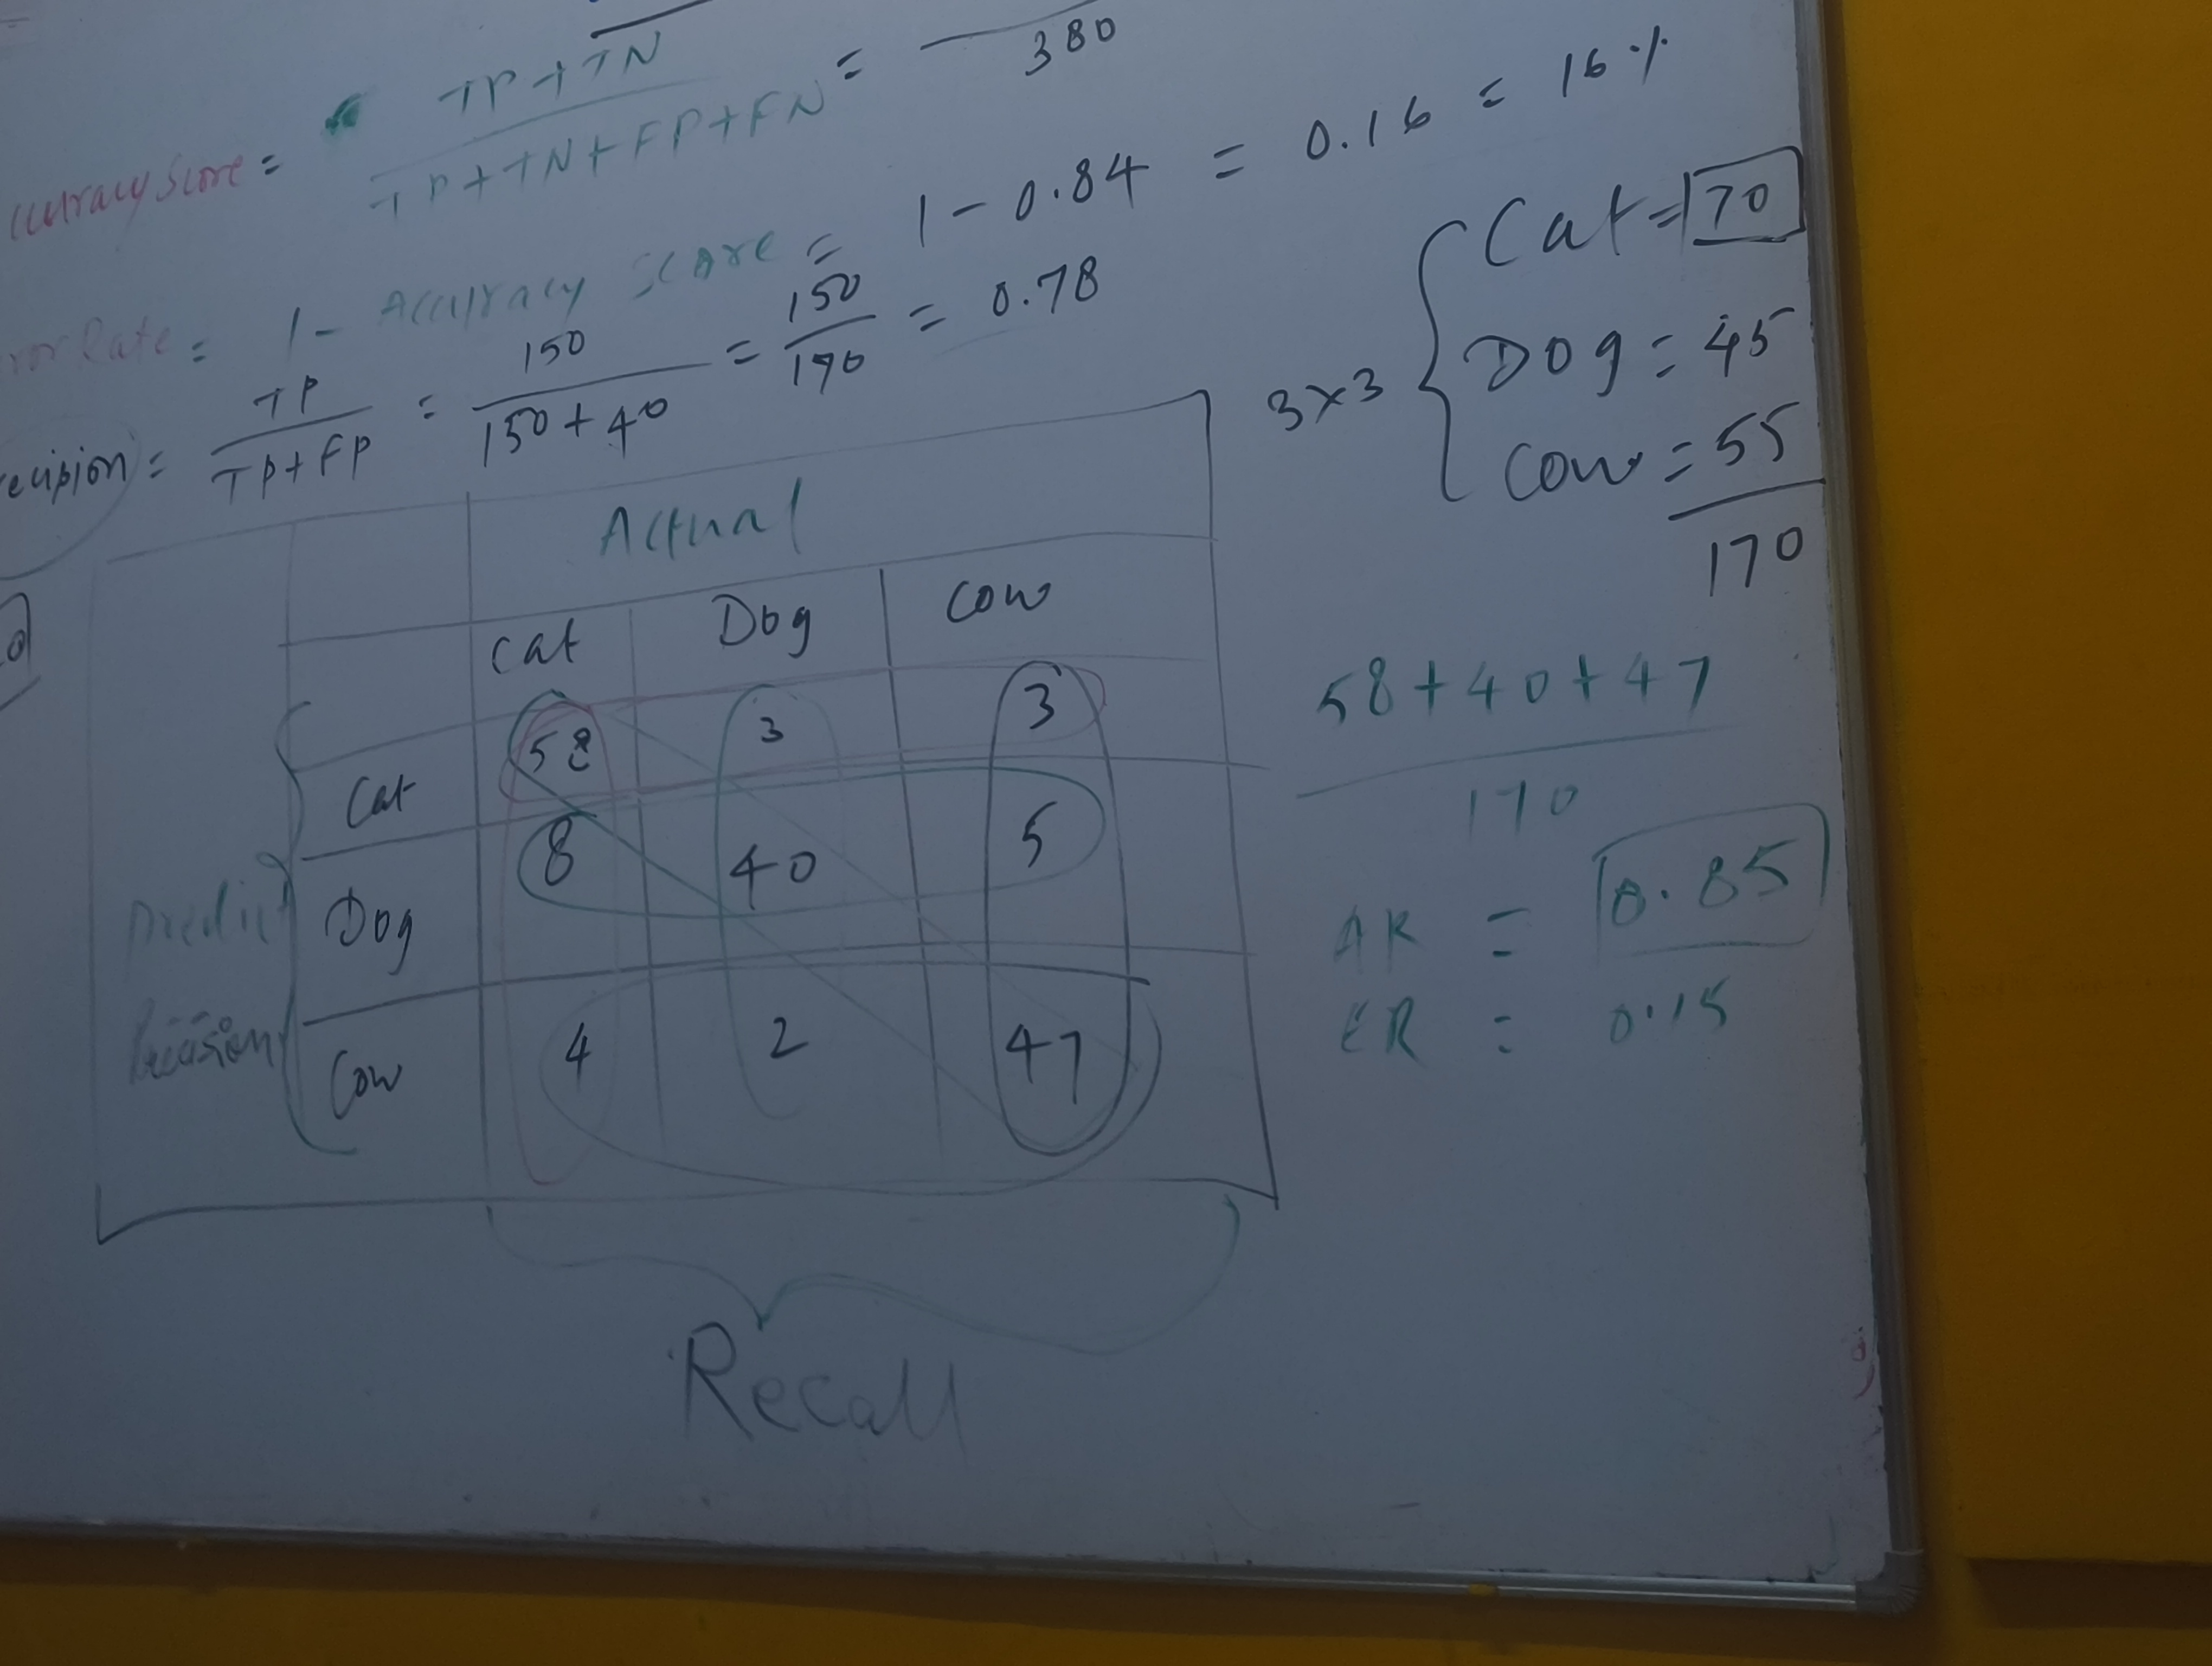

- last image me cat,dog,cow ka precision and recall calculate kiya hai.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk 
import warnings

warnings.filterwarnings('ignore')


In [2]:
Titanic_df = pd.read_csv(r'D:\AI & ML\Machine_Learning_19\Dataset\Titanic-Dataset.csv')
Titanic_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# EDA

In [3]:
Titanic_df.shape

(891, 12)

In [4]:
Titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
Titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data cleaning

### Drop unwanted columns.

In [6]:
Titanic_df.drop(['PassengerId','Name','Cabin','Ticket'], axis=1, inplace=True)
Titanic_df.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S


In [7]:
Titanic_df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [8]:
Titanic_df['Age'] = Titanic_df['Age'].fillna(Titanic_df['Age'].mean())
Titanic_df['Embarked'] = Titanic_df['Embarked'].fillna(Titanic_df["Embarked"].mode()[0])

In [9]:
Titanic_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## Feature Encoding

In [10]:
Titanic_df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [11]:
Titanic_df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [12]:
Titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
catego_col = Titanic_df.select_dtypes(include='object').columns
catego_col

Index(['Sex', 'Embarked'], dtype='object')

# Feature Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder


for i in catego_col:
    Titanic_df[i] = LabelEncoder().fit_transform(Titanic_df[i])

Titanic_df.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2


## Feature Extraction

In [15]:
Independent = Titanic_df.drop('Survived',axis= 1)

Dependent = Titanic_df['Survived']

In [16]:
Independent

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.000000,1,0,7.2500,2
1,1,0,38.000000,1,0,71.2833,0
2,3,0,26.000000,0,0,7.9250,2
3,1,0,35.000000,1,0,53.1000,2
4,3,1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,2
887,1,0,19.000000,0,0,30.0000,2
888,3,0,29.699118,1,2,23.4500,2
889,1,1,26.000000,0,0,30.0000,0


In [17]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(Independent,Dependent,test_size=0.3 , random_state=65, stratify = Dependent) # for stoping suffling
 # stratify use for 70 and 30


In [18]:
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(623, 7) (268, 7)
(623,) (268,)


## Model bulding

In [19]:
from sklearn.linear_model import LogisticRegression
train_model = LogisticRegression().fit(X_train,Y_train)


In [20]:
predict = train_model.predict(X_test)
predict[:8]

array([0, 0, 1, 0, 1, 0, 1, 0], dtype=int64)

In [21]:
Y_test

0      0
881    0
550    1
335    0
576    1
      ..
318    1
590    0
248    1
332    0
634    0
Name: Survived, Length: 268, dtype: int64

In [22]:
actual_pre = pd.DataFrame({'Actual':Y_test,
                        'Prediction':predict
                           })
actual_pre

,Actual,Prediction
0,0,0
881,0,0
550,1,1
335,0,0
576,1,1
...,...,...
318,1,1
590,0,0
248,1,0
332,0,0


In [23]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,classification_report,recall_score,f1_score

print('Confusinon Matrix')
print(confusion_matrix(Y_test,predict))

Confusinon Matrix
[[145  20]
 [ 27  76]]


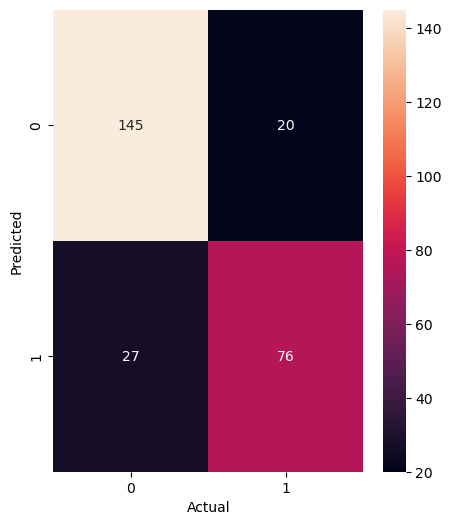

In [24]:
plt.figure(figsize=(5,6))
sns.heatmap(confusion_matrix(Y_test,predict),annot=True, fmt='d' )

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

- 140 means TN true nagative means predicted  me bhi mar gaye or actual me bhi mar gaye hai yaha marne ko negative bola hai.


In [25]:
print(f'accuracy score = ',accuracy_score(Y_test,predict)*100)
print(f'Precision score = ',precision_score(Y_test,predict)*100)
print(f'Recall score = ',recall_score(Y_test,predict)*100)
print(f'F1_score= ',f1_score(Y_test,predict)*100)

accuracy score =  82.46268656716418
Precision score =  79.16666666666666
Recall score =  73.7864077669903
F1_score=  76.38190954773869


In [26]:
import pickle
with open("Titanic_survive_log_model.pkl","wb") as file:
    pickle.dump(train_model,file)

In [27]:
with open(r'D:\AI & ML\Machine_Learning_19\Supervise_learning\Classification\Titanic_survive_log_model.pkl','rb') as file:
    model = pickle.load(file)


In [28]:
new_array = np.array([[3,1,22,1,0,7,2]])
pred = model.predict(new_array)

pred

array([0], dtype=int64)